In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
base_dir = Path.cwd().parent
processed_dir = base_dir / "data" / "processed"
figures_dir = base_dir / "outputs" / "figures"

figures_dir.mkdir(parents=True, exist_ok=True)

In [3]:
games = pd.read_csv(processed_dir / "games_cleaned.csv")
users = pd.read_csv(processed_dir / "users_cleaned.csv")
user_features = pd.read_csv(processed_dir / "user_features.csv")
user_segments = pd.read_csv(processed_dir / "user_segments.csv")

print("Games:", games.shape)
print("Users:", users.shape)
print("User Features:", user_features.shape)
print("User Segments:", user_segments.shape)

Games: (50872, 20)
Users: (14306064, 3)
User Features: (14306064, 9)
User Segments: (13655817, 2)


In [4]:
print("Games columns")
print(games.columns.tolist())

Games columns
['app_id', 'title', 'date_release', 'win', 'mac', 'linux', 'rating', 'positive_ratio', 'user_reviews', 'price_final', 'price_original', 'discount', 'steam_deck', 'rating_score', 'release_year', 'release_month', 'is_free', 'price_change', 'discount_rate', 'platform_count']


In [5]:
print("\nUser Features columns")
print(user_features.columns.tolist())


User Features columns
['user_id', 'products', 'reviews', 'reviews_per_product', 'recommendation_count', 'recommend_rate', 'avg_hours', 'avg_helpful', 'avg_funny']


In [6]:
print("\nUser Segments columns")
print(user_segments.columns.tolist())


User Segments columns
['user_id', 'cluster']


In [7]:
display(games.head())
display(user_features.head())
display(user_segments.head())

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,price_original,discount,steam_deck,rating_score,release_year,release_month,is_free,price_change,discount_rate,platform_count
0,13500,Prince of Persia: Warrior Within™,2008-11-21,True,False,False,Very Positive,84,2199,9.99,9.99,0.0,True,8,2008,11,False,0.0,0.0,1
1,22364,BRINK: Agents of Change,2011-08-03,True,False,False,Positive,85,21,2.99,2.99,0.0,True,7,2011,8,False,0.0,0.0,1
2,113020,Monaco: What's Yours Is Mine,2013-04-24,True,True,True,Very Positive,92,3722,14.99,14.99,0.0,True,8,2013,4,False,0.0,0.0,3
3,226560,Escape Dead Island,2014-11-18,True,False,False,Mixed,61,873,14.99,14.99,0.0,True,5,2014,11,False,0.0,0.0,1
4,249050,Dungeon of the ENDLESS™,2014-10-27,True,True,False,Very Positive,88,8784,11.99,11.99,0.0,True,8,2014,10,False,0.0,0.0,2


,user_id,products,reviews,reviews_per_product,recommendation_count,recommend_rate,avg_hours,avg_helpful,avg_funny
0,7360263,359,0,0.000000,0.0,0.00,0.000,0.00,0.0
1,14020781,156,1,0.006410,1.0,1.00,515.900,0.00,0.0
2,8762579,329,4,0.012158,4.0,0.75,136.250,4.25,0.5
3,4820647,176,4,0.022727,4.0,1.00,78.225,0.00,0.0
4,5167327,98,2,0.020408,2.0,0.50,581.050,1.00,0.0


,user_id,cluster
0,14020781,0
1,8762579,1
2,4820647,1
3,5167327,2
4,5664667,1


#### Games 기본 분포

In [8]:
games.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
app_id,50872.0,NaN,NaN,NaN,1055223.805099,610324.945457,10.0,528737.5,986085.0,1524895.0,2599300.0
title,50872,50751,Loop,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_release,50872,4292,2020-06-18,92,NaN,NaN,NaN,NaN,NaN,NaN,NaN
win,50872,2,True,50076,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mac,50872,2,False,37854,NaN,NaN,NaN,NaN,NaN,NaN,NaN
linux,50872,2,False,41831,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,50872,9,Positive,13502,NaN,NaN,NaN,NaN,NaN,NaN,NaN
positive_ratio,50872.0,NaN,NaN,NaN,77.052033,18.253592,0.0,67.0,81.0,91.0,100.0
user_reviews,50872.0,NaN,NaN,NaN,1824.424988,40073.521653,10.0,19.0,49.0,206.0,7494460.0
price_final,50872.0,NaN,NaN,NaN,8.620325,11.514164,0.0,0.99,4.99,10.99,299.99


## visualization

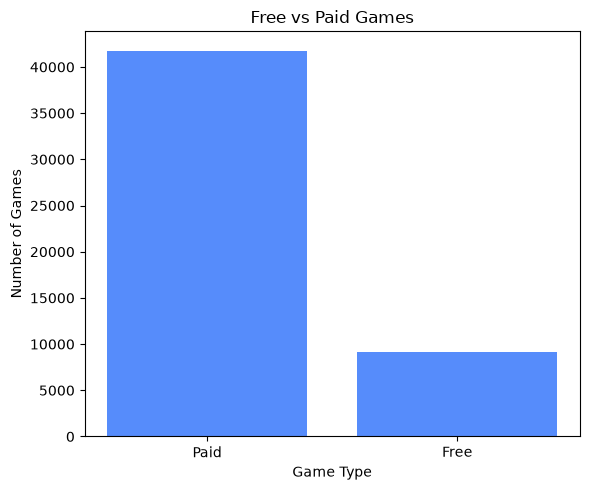

In [15]:
# Free vs Paid

free_count = games["is_free"].astype(bool).sum()
paid_count = len(games) - free_count

game_type = pd.Series(
    [paid_count, free_count],
    index=["Paid", "Free"]
)

plt.figure(figsize=(6, 5))

plt.bar(
    game_type.index,
    game_type.values
)

plt.title("Free vs Paid Games")
plt.xlabel("Game Type")
plt.ylabel("Number of Games")

plt.tight_layout()

plt.savefig(
    figures_dir / "01_free_vs_paid.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

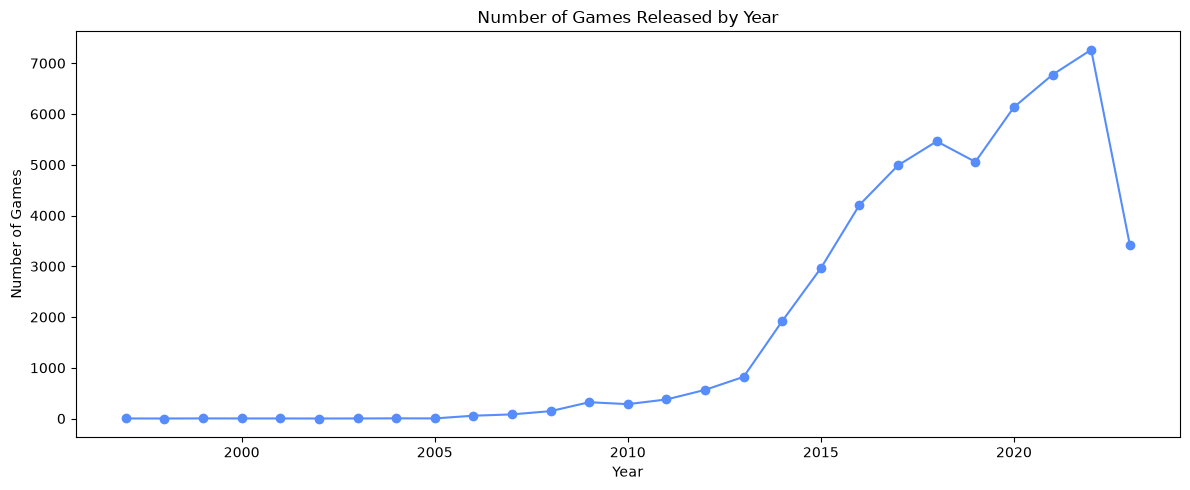

In [16]:
# Games Released by Year

release_year = (
    games["release_year"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 5))

plt.plot(
    release_year.index,
    release_year.values,
    marker="o"
)

plt.title("Number of Games Released by Year")
plt.xlabel("Year")
plt.ylabel("Number of Games")

plt.tight_layout()

plt.savefig(
    figures_dir / "02_games_released_by_year.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

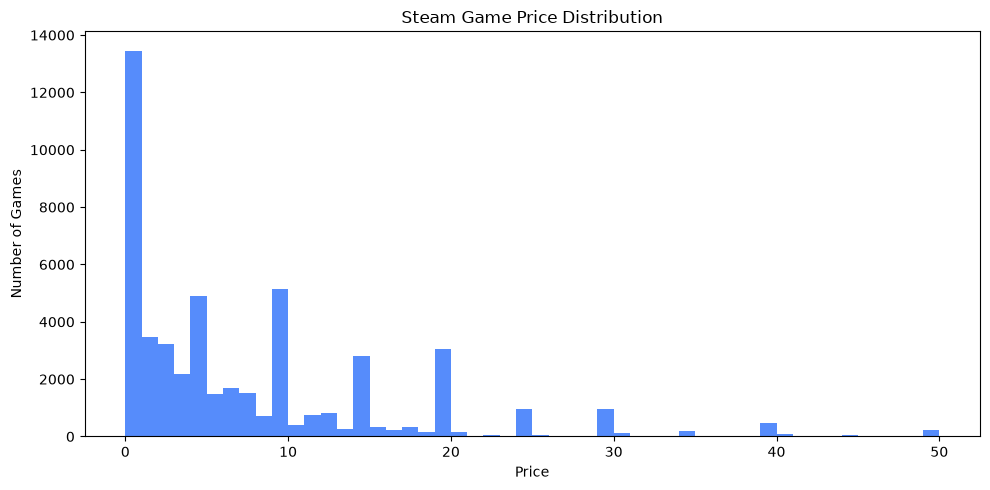

In [17]:
# Price Distribution

price_99 = games["price_final"].quantile(0.99)

price_data = games.loc[
    games["price_final"] <= price_99,
    "price_final"
].dropna()

plt.figure(figsize=(10, 5))

plt.hist(
    price_data,
    bins=50
)

plt.title("Steam Game Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Games")

plt.tight_layout()

plt.savefig(
    figures_dir / "03_price_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

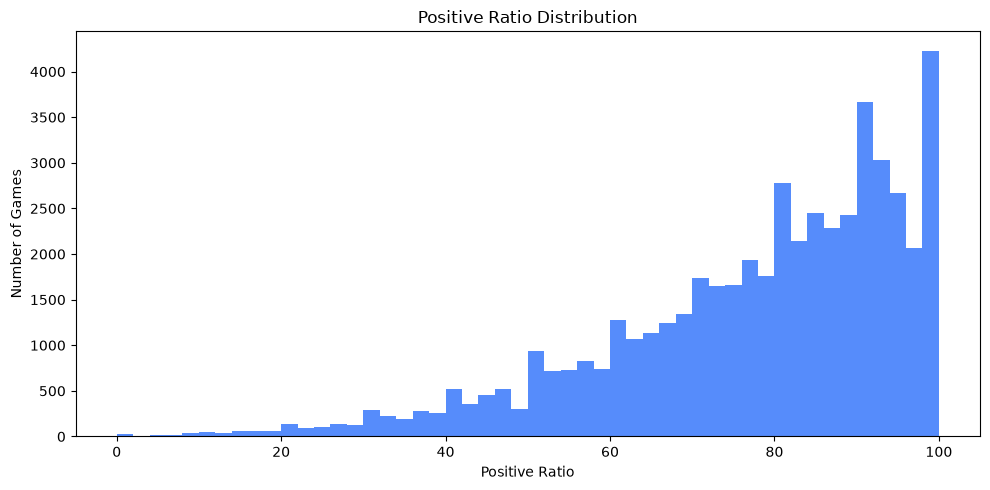

In [18]:
# Positive Ratio Distribution

positive_ratio = games["positive_ratio"].dropna()

plt.figure(figsize=(10, 5))

plt.hist(
    positive_ratio,
    bins=50
)

plt.title("Positive Ratio Distribution")
plt.xlabel("Positive Ratio")
plt.ylabel("Number of Games")

plt.tight_layout()

plt.savefig(
    figures_dir / "04_positive_ratio_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

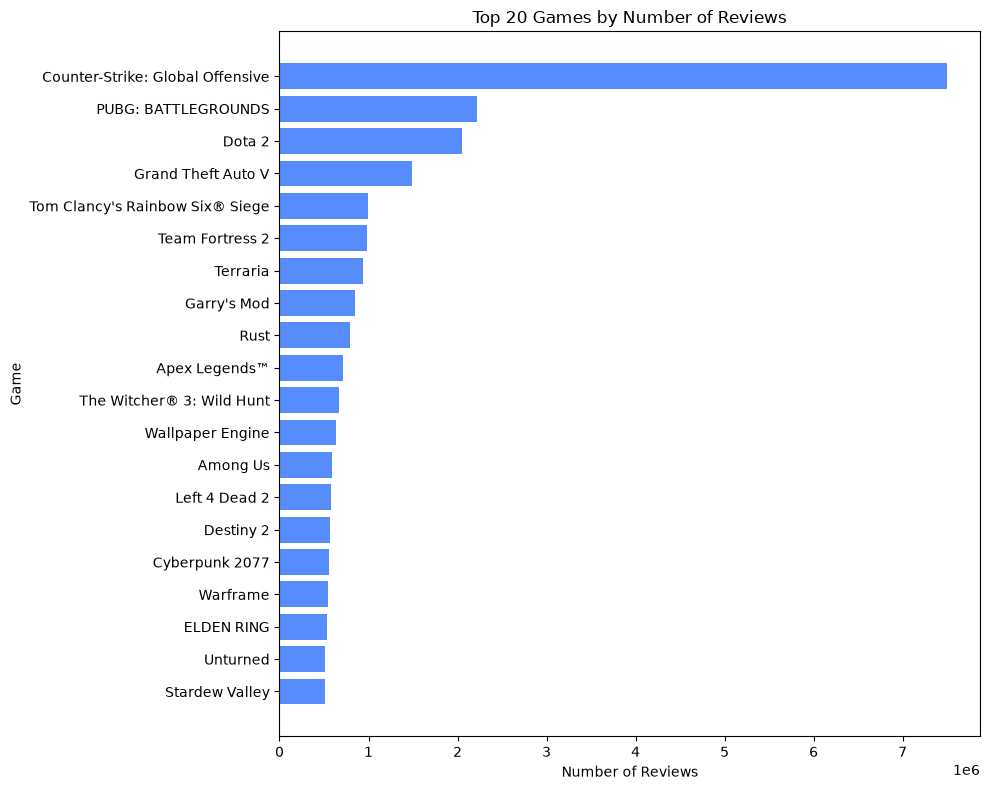

In [19]:
# Top 20 Games by Reviews

top_reviewed = (
    games[["title", "user_reviews"]]
    .dropna()
    .sort_values("user_reviews", ascending=False)
    .head(20)
    .sort_values("user_reviews")
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_reviewed["title"],
    top_reviewed["user_reviews"]
)

plt.title("Top 20 Games by Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Game")

plt.tight_layout()

plt.savefig(
    figures_dir / "05_top20_games_by_reviews.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

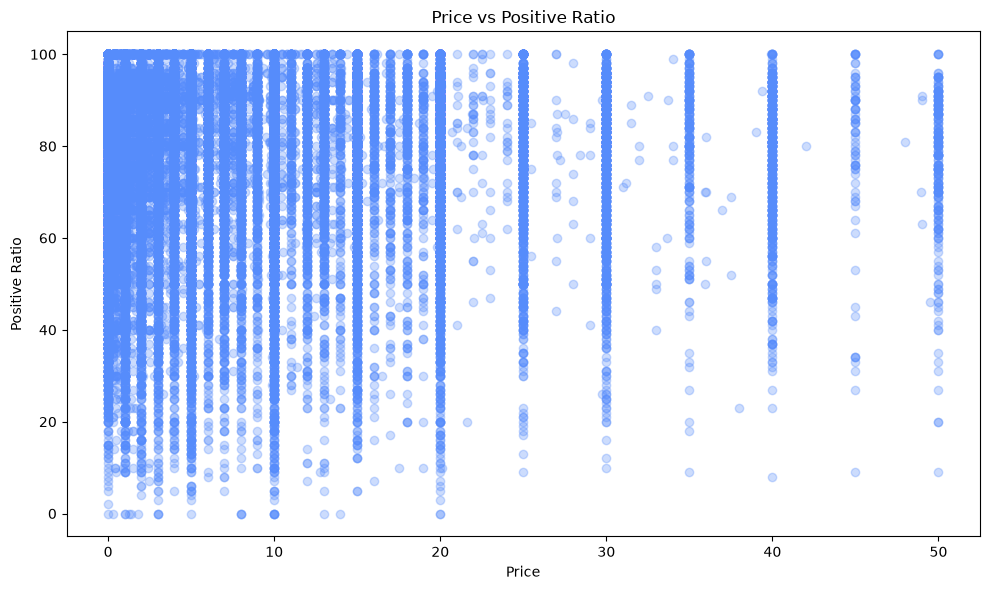

In [20]:
# Price vs Positive Ratio

price_rating = games[
    ["price_final", "positive_ratio"]
].dropna()

price_99 = price_rating["price_final"].quantile(0.99)

price_rating = price_rating[
    price_rating["price_final"] <= price_99
]

plt.figure(figsize=(10, 6))

plt.scatter(
    price_rating["price_final"],
    price_rating["positive_ratio"],
    alpha=0.3
)

plt.title("Price vs Positive Ratio")
plt.xlabel("Price")
plt.ylabel("Positive Ratio")

plt.tight_layout()

plt.savefig(
    figures_dir / "06_price_vs_positive_ratio.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

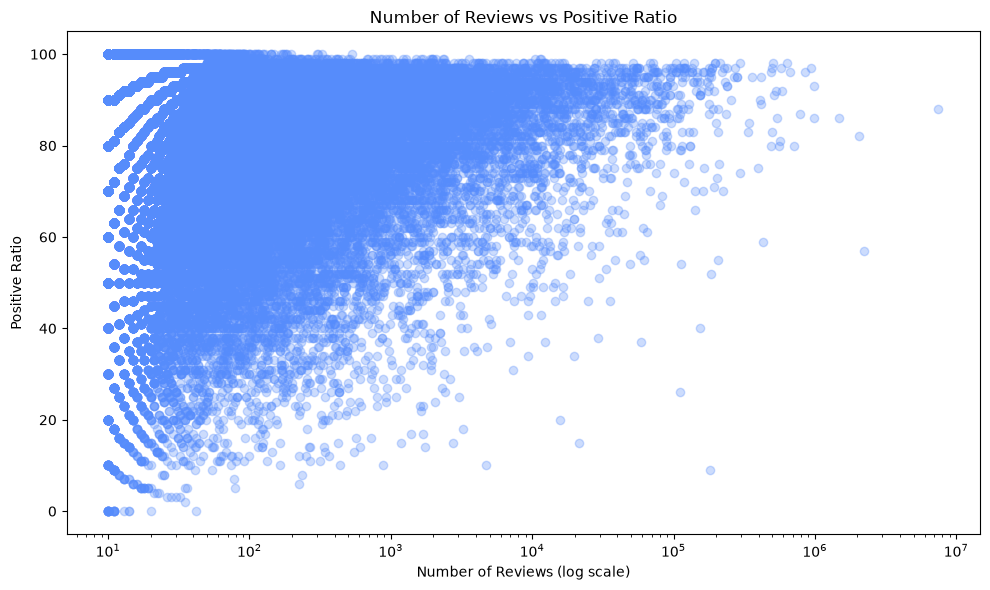

In [21]:
# Reviews vs Positive Ratio

review_rating = games[
    ["user_reviews", "positive_ratio"]
].dropna()

review_rating = review_rating[
    review_rating["user_reviews"] > 0
]

plt.figure(figsize=(10, 6))

plt.scatter(
    review_rating["user_reviews"],
    review_rating["positive_ratio"],
    alpha=0.3
)

plt.xscale("log")

plt.title("Number of Reviews vs Positive Ratio")
plt.xlabel("Number of Reviews (log scale)")
plt.ylabel("Positive Ratio")

plt.tight_layout()

plt.savefig(
    figures_dir / "07_reviews_vs_positive_ratio.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

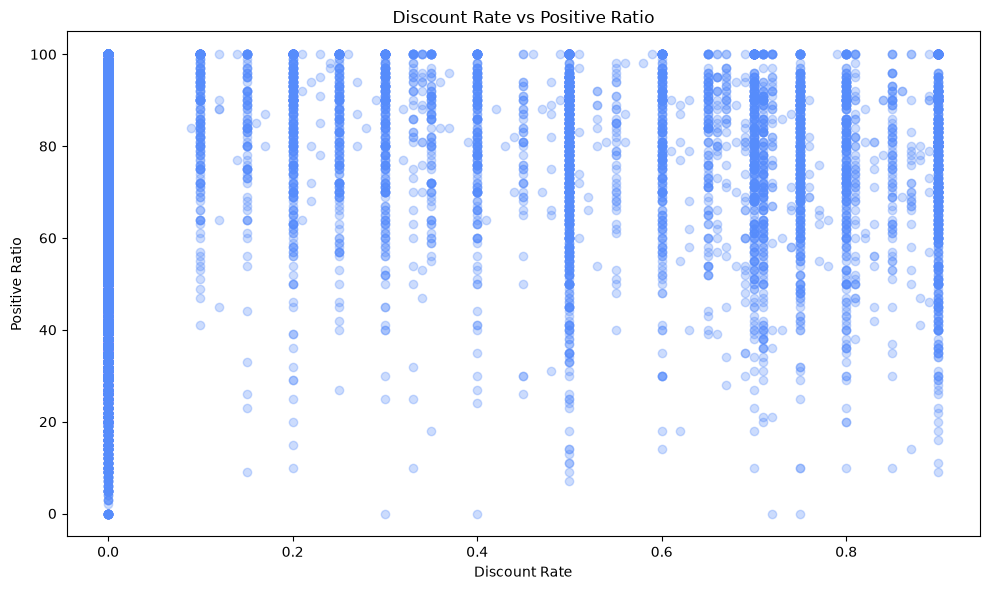

In [22]:
# Discount Rate vs Positive Ratio

discount_rating = games[
    ["discount_rate", "positive_ratio"]
].dropna()

plt.figure(figsize=(10, 6))

plt.scatter(
    discount_rating["discount_rate"],
    discount_rating["positive_ratio"],
    alpha=0.3
)

plt.title("Discount Rate vs Positive Ratio")
plt.xlabel("Discount Rate")
plt.ylabel("Positive Ratio")

plt.tight_layout()

plt.savefig(
    figures_dir / "08_discount_vs_positive_ratio.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

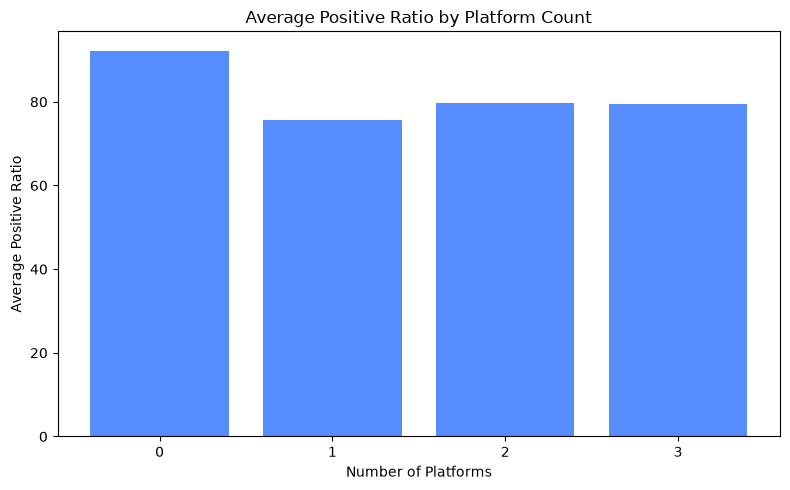

In [23]:
# Platform Count vs Positive Ratio

platform_summary = (
    games
    .dropna(subset=["platform_count", "positive_ratio"])
    .groupby("platform_count")["positive_ratio"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    platform_summary.index.astype(str),
    platform_summary.values
)

plt.title("Average Positive Ratio by Platform Count")
plt.xlabel("Number of Platforms")
plt.ylabel("Average Positive Ratio")

plt.tight_layout()

plt.savefig(
    figures_dir / "09_platform_count_vs_positive_ratio.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

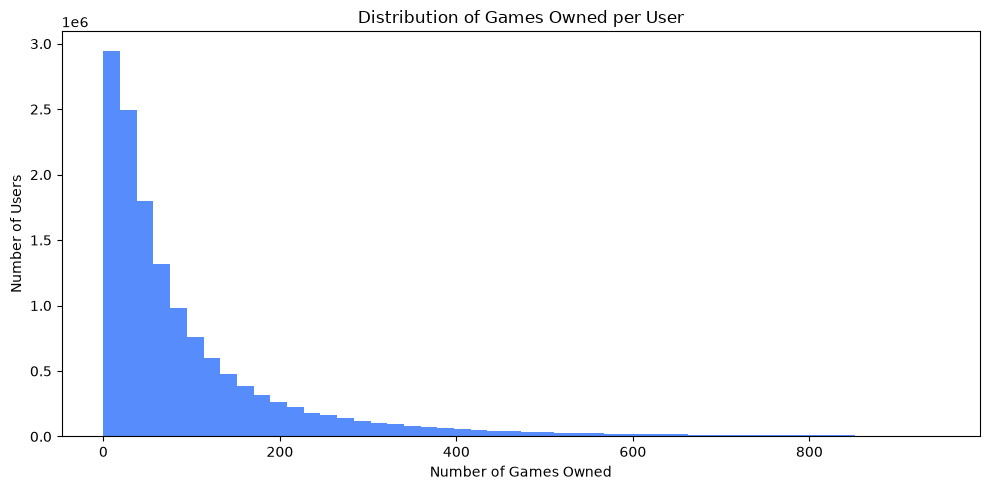

In [24]:
# Games Owned per User

products_99 = user_features["products"].quantile(0.99)

products = user_features.loc[
    user_features["products"] <= products_99,
    "products"
].dropna()

plt.figure(figsize=(10, 5))

plt.hist(
    products,
    bins=50
)

plt.title("Distribution of Games Owned per User")
plt.xlabel("Number of Games Owned")
plt.ylabel("Number of Users")

plt.tight_layout()

plt.savefig(
    figures_dir / "10_user_products_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

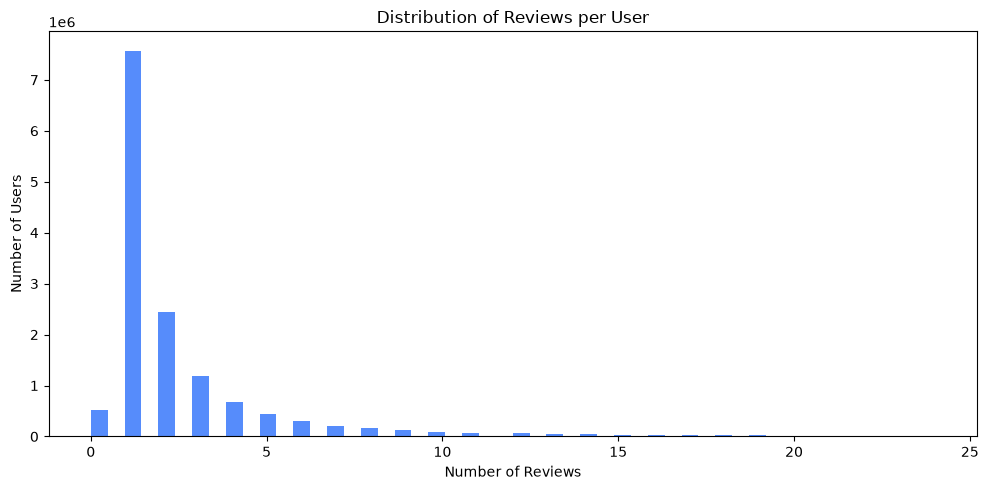

In [25]:
# Reviews per User

reviews_99 = user_features["reviews"].quantile(0.99)

reviews = user_features.loc[
    user_features["reviews"] <= reviews_99,
    "reviews"
].dropna()

plt.figure(figsize=(10, 5))

plt.hist(
    reviews,
    bins=50
)

plt.title("Distribution of Reviews per User")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Users")

plt.tight_layout()

plt.savefig(
    figures_dir / "11_user_reviews_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

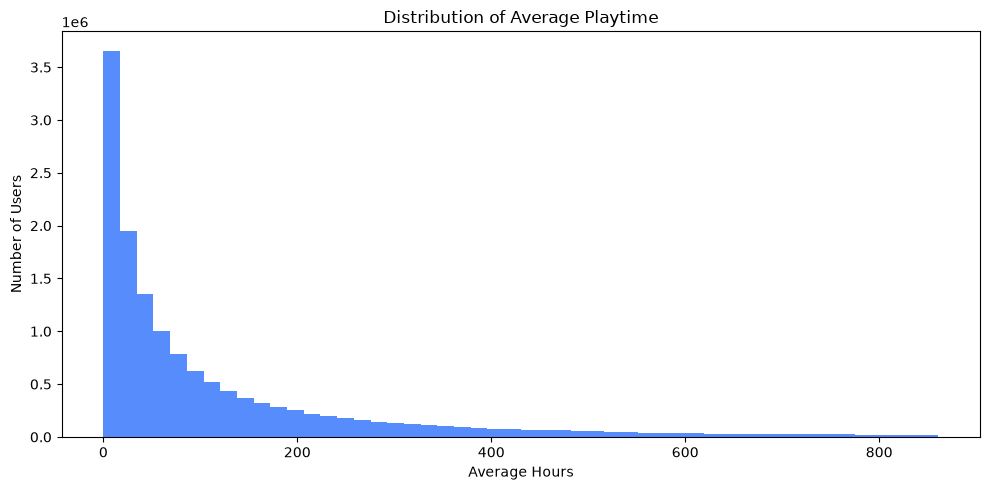

In [27]:
# Average Playtime

hours_99 = user_features["avg_hours"].quantile(0.99)

hours = user_features.loc[
    user_features["avg_hours"] <= hours_99,
    "avg_hours"
].dropna()

plt.figure(figsize=(10, 5))

plt.hist(
    hours,
    bins=50
)

plt.title("Distribution of Average Playtime")
plt.xlabel("Average Hours")
plt.ylabel("Number of Users")

plt.tight_layout()

plt.savefig(
    figures_dir / "12_average_playtime_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

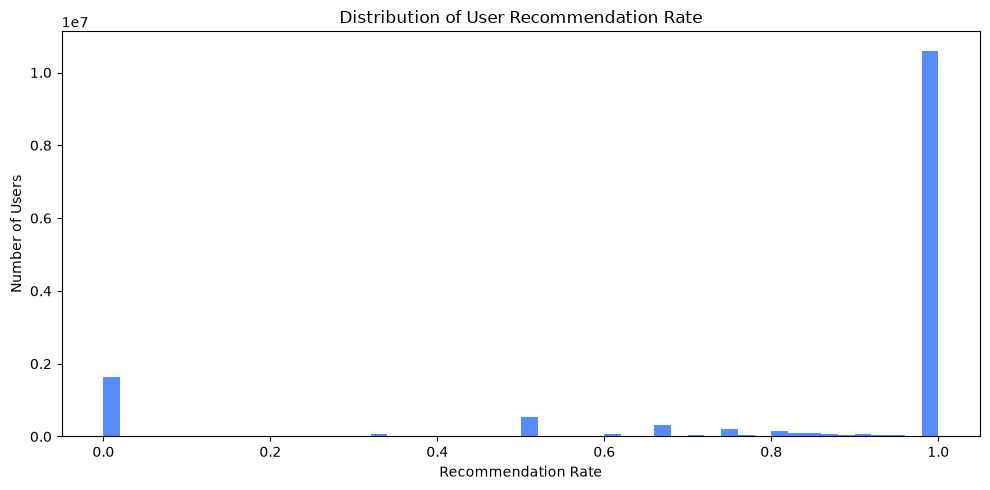

In [28]:
# Recommendation Rate

recommend_rate = user_features[
    "recommend_rate"
].dropna()

plt.figure(figsize=(10, 5))

plt.hist(
    recommend_rate,
    bins=50
)

plt.title("Distribution of User Recommendation Rate")
plt.xlabel("Recommendation Rate")
plt.ylabel("Number of Users")

plt.tight_layout()

plt.savefig(
    figures_dir / "13_recommendation_rate_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

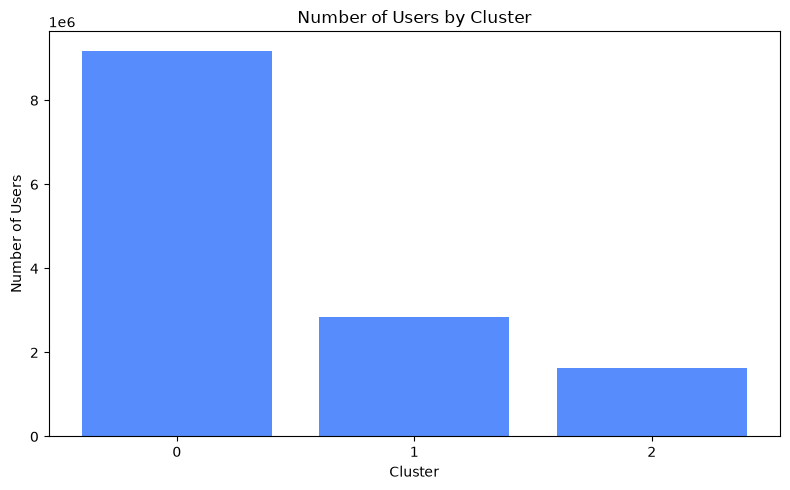

In [29]:
# Number of Users by Cluster

cluster_counts = (
    user_segments["cluster"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.title("Number of Users by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Users")

plt.tight_layout()

plt.savefig(
    figures_dir / "14_users_by_cluster.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

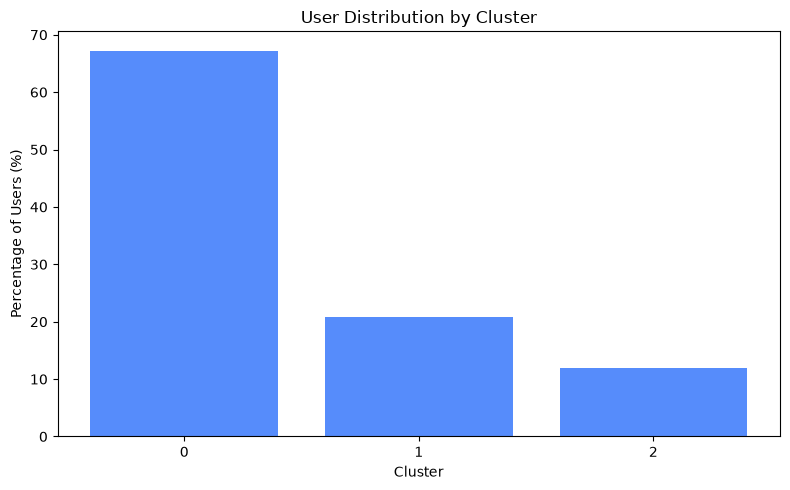

In [31]:
# User Distribution by Cluster

cluster_percentage = (
    user_segments["cluster"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_percentage.index.astype(str),
    cluster_percentage.values
)

plt.title("User Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Percentage of Users (%)")

plt.tight_layout()

plt.savefig(
    figures_dir / "15_cluster_percentage.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

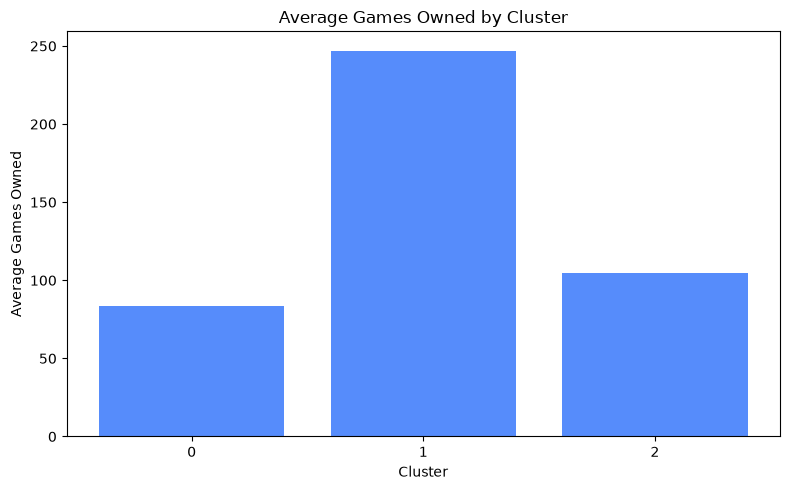

In [32]:
# Average Games Owned by Cluster

user_clustered = user_features.merge(
    user_segments,
    on="user_id",
    how="inner"
)

cluster_products = (
    user_clustered
    .groupby("cluster")["products"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_products.index.astype(str),
    cluster_products.values
)

plt.title("Average Games Owned by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Games Owned")

plt.tight_layout()

plt.savefig(
    figures_dir / "16_cluster_avg_products.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

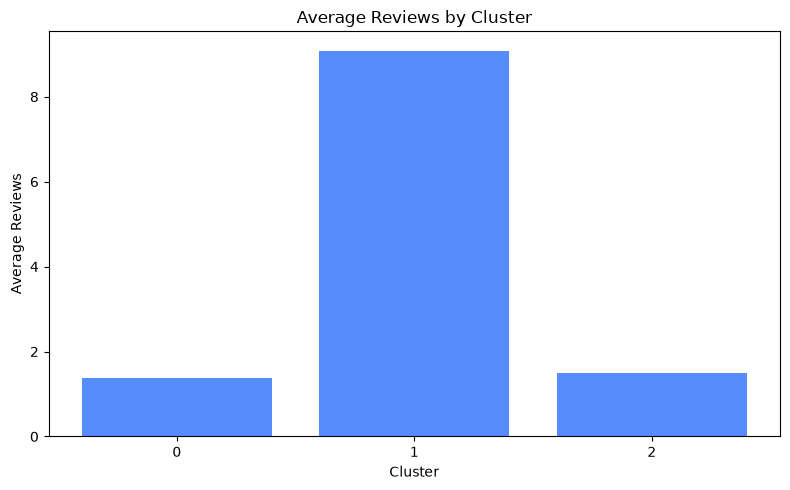

In [33]:
# Average Reviews by Cluster

cluster_reviews = (
    user_clustered
    .groupby("cluster")["reviews"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_reviews.index.astype(str),
    cluster_reviews.values
)

plt.title("Average Reviews by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Reviews")

plt.tight_layout()

plt.savefig(
    figures_dir / "17_cluster_avg_reviews.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

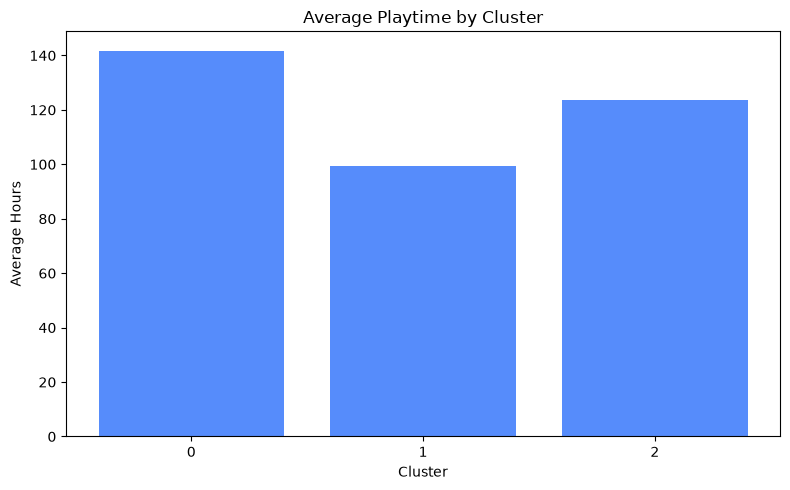

In [34]:
# Average Playtime by Cluster

cluster_hours = (
    user_clustered
    .groupby("cluster")["avg_hours"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_hours.index.astype(str),
    cluster_hours.values
)

plt.title("Average Playtime by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Hours")

plt.tight_layout()

plt.savefig(
    figures_dir / "18_cluster_avg_hours.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

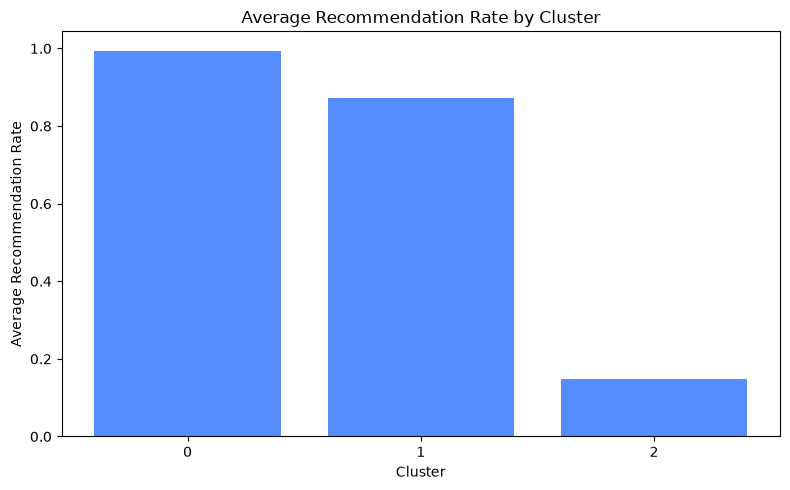

In [35]:
# Average Recommendation Rate by Cluster

cluster_recommend = (
    user_clustered
    .groupby("cluster")["recommend_rate"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_recommend.index.astype(str),
    cluster_recommend.values
)

plt.title("Average Recommendation Rate by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Recommendation Rate")

plt.tight_layout()

plt.savefig(
    figures_dir / "19_cluster_recommendation_rate.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [37]:
# Cluster Summary

cluster_summary = (
    user_clustered
    .groupby("cluster")
    .agg(
        users=("user_id", "count"),
        avg_products=("products", "mean"),
        avg_reviews=("reviews", "mean"),
        avg_reviews_per_product=("reviews_per_product", "mean"),
        avg_recommendation_count=("recommendation_count", "mean"),
        avg_recommend_rate=("recommend_rate", "mean"),
        avg_hours=("avg_hours", "mean"),
        avg_helpful=("avg_helpful", "mean"),
        avg_funny=("avg_funny", "mean")
    )
    .round(2)
)

display(cluster_summary)

,users,avg_products,avg_reviews,avg_reviews_per_product,avg_recommendation_count,avg_recommend_rate,avg_hours,avg_helpful,avg_funny
cluster,,,,,,,,,
0,9181826,83.30,1.38,0.06,1.38,0.99,141.77,1.74,0.73
1,2851721,247.04,9.08,0.08,9.08,0.87,99.21,3.13,1.12
2,1622270,104.94,1.49,0.05,1.49,0.15,123.50,5.13,1.16
